# EDA :

### Feature/Label Seperation

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/processed/processed_data.csv")

X=df.drop(['Label','Binary_Label'],axis=1)
y=df["Binary_Label"]

print(X.shape)
print(y.shape)

(1820417, 10)
(1820417,)


### Class Distribution

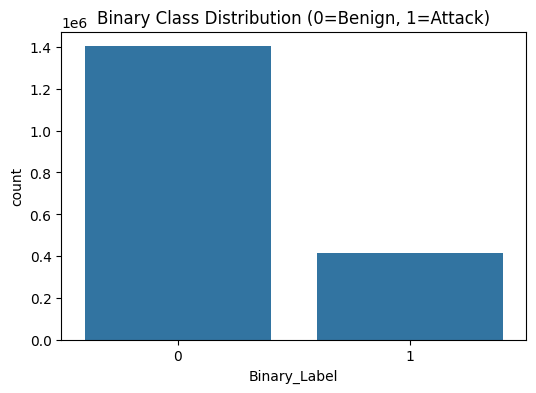

Binary_Label
0    77.144028
1    22.855972
Name: proportion, dtype: float64


In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Binary Class Distribution (0=Benign, 1=Attack)")
plt.show()

print(y.value_counts(normalize=True)*100)

### Statistical summary (mean,median,mean_meadian_differnce,std etc..)

In [30]:
summary = X.describe().T
summary['median']=X.median()
summary['mean_median_diff']=summary['mean']-summary['median']

print(summary[['mean','median','std','min','max','mean_median_diff']])

                                     mean   median           std   min  \
Destination Port             8.722457e+03     80.0  1.878356e+04   0.0   
Flow Duration                1.993713e+07  79020.0  3.781005e+07 -13.0   
Total Fwd Packets            1.102243e+01      2.0  8.012960e+02   1.0   
Total Backward Packets       1.251737e+01      2.0  1.070566e+03   0.0   
Total Length of Fwd Packets  6.858292e+02     66.0  1.199639e+04   0.0   
Total Length of Bwd Packets  1.989797e+04    166.0  2.424919e+06   0.0   
Packet Length Mean           2.291612e+02     67.0  3.559903e+02   0.0   
SYN Flag Count               4.616470e-02      0.0  2.098417e-01   0.0   
ACK Flag Count               3.198416e-01      0.0  4.664151e-01   0.0   
RST Flag Count               3.367360e-04      0.0  1.834728e-02   0.0   

                                      max  mean_median_diff  
Destination Port             6.553300e+04      8.642457e+03  
Flow Duration                1.200000e+08      1.985811e+07  

### Skewed feature detection and Plot

#### 1. Skewness detection

In [31]:
skew_values = X.skew()
highly_skewed=skew_values[skew_values>3]
highly_skewed=highly_skewed.sort_values(ascending=False)

print(highly_skewed.shape)
print(highly_skewed.head(10))


(6,)
Total Length of Fwd Packets    718.052293
Total Length of Bwd Packets    221.355602
Total Backward Packets         220.996928
Total Fwd Packets              220.732562
RST Flag Count                  54.467333
SYN Flag Count                   4.325506
dtype: float64


#### 2. Skewness Plot

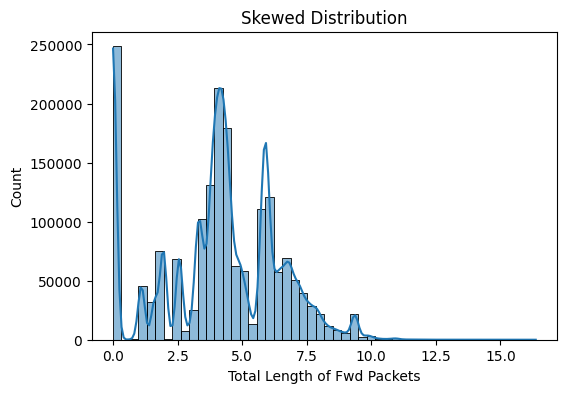

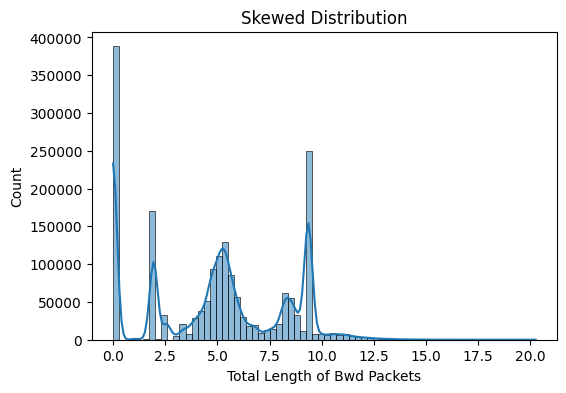

In [32]:
#Skewness plot of "Total Length of Fwd Packets"
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(X["Total Length of Fwd Packets"]), bins=50, kde=True)
plt.title("Skewed Distribution")
plt.show()

#Skewness plot of "act_data_pkt_fwd"
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(X["Total Length of Bwd Packets"]),bins=70,kde=True)
plt.title("Skewed Distribution")
plt.show()

### Attack vs Normal (Feature vs Label) analysis

c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


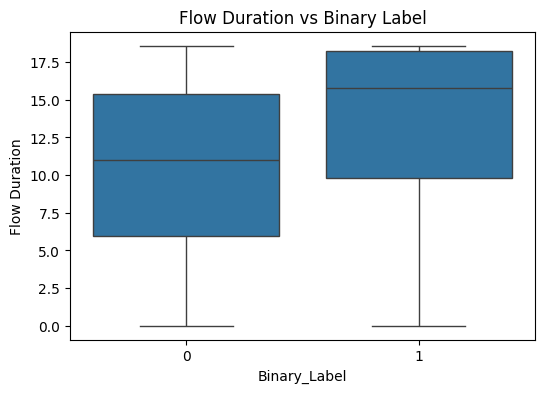

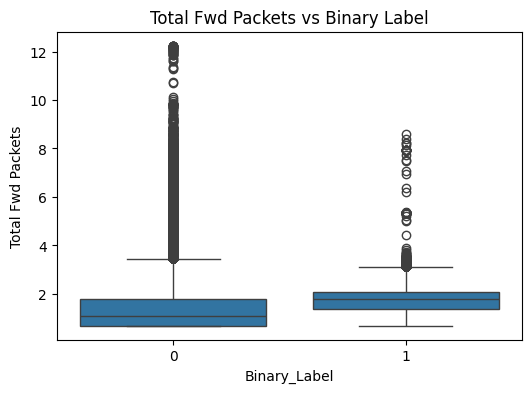

In [33]:
features = ["Flow Duration", "Total Fwd Packets"]

for col in features:
    if col in X.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=y, y=np.log1p(X[col]))
        plt.title(f"{col} vs Binary Label")
        plt.show()

 ### Correlation Analysis

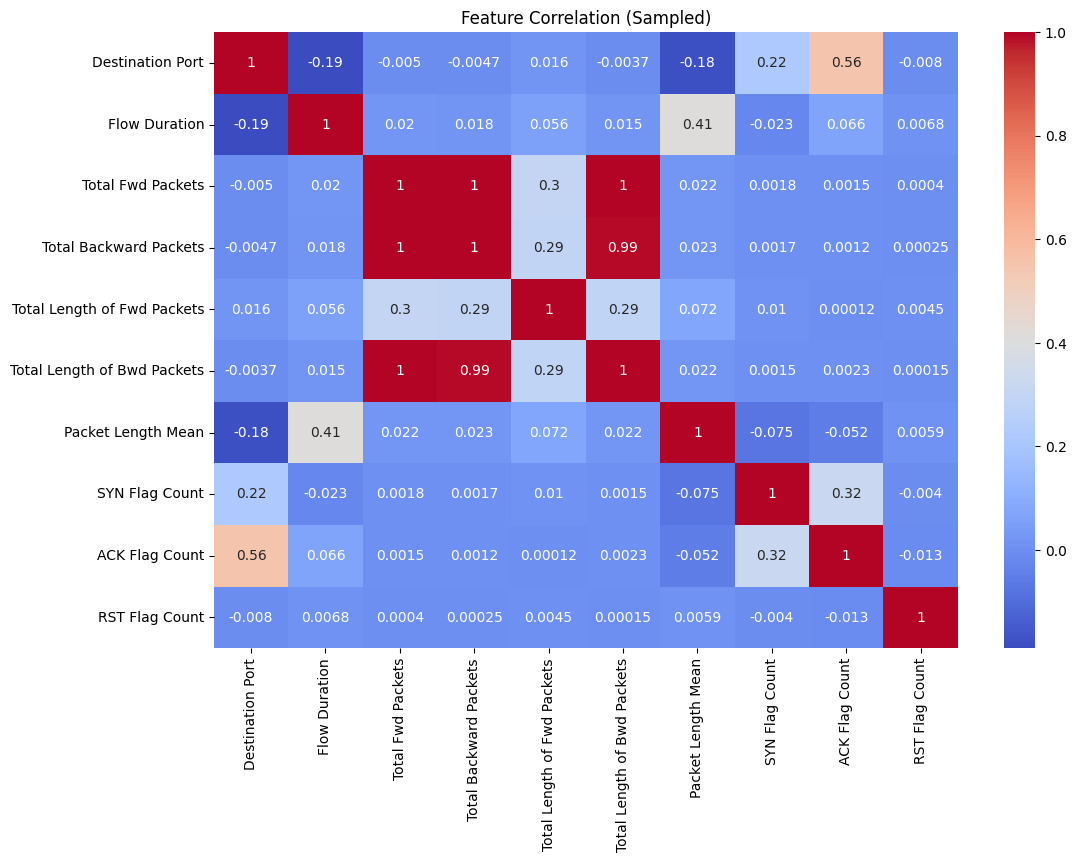

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation (Sampled)")
plt.show()

Feature Importance Plot

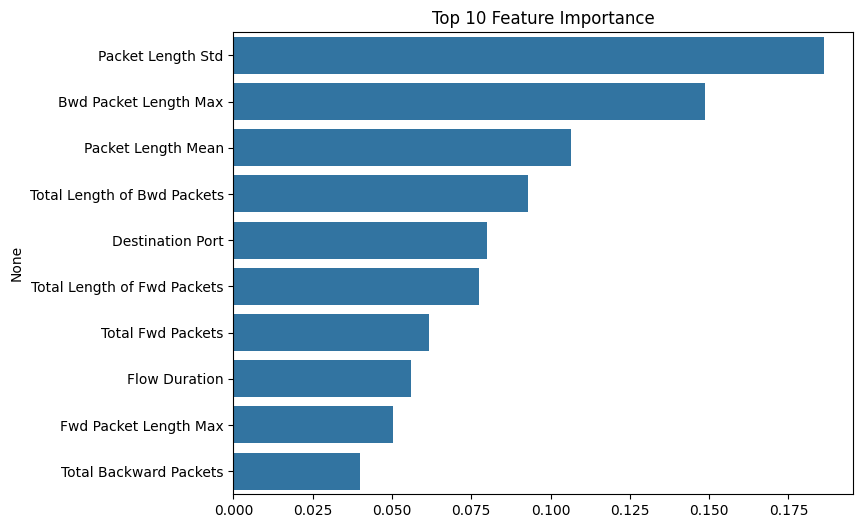

In [10]:
from sklearn.ensemble import RandomForestClassifier



skew_values = X.skew()
highly_skewed = skew_values[skew_values > 3]

X_log = X.copy()

for col in highly_skewed.index:
    if (X_log[col] < 0).any():
        X_log[col] = X_log[col] - X_log[col].min()
    X_log[col] = np.log1p(X_log[col])

# sample for faster training
sample_size = 200000
sample = X_log.sample(sample_size, random_state=42)
y_sample = y.loc[sample.index]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(sample, y_sample)

importance = rf.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X_log.columns
).sort_values(ascending=False)

top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Feature Importance")
plt.show()